# **APE11: Inferencia Estadística Multigrupo: Análisis de Varianza (ANOVA de 1 factor) y Pruebas Post-Hoc (Tukey)**
###***Universidad Nacional de Loja***

**Grupo B - Integrantes:**
* Arlette Quezada
* Roy Gordillo
* Eduardo Soto
* Danny Beltran
* Pablo Pineda


## Tarea 1: Análisis de Varianza (ANOVA de 1 factor)

El ANOVA compara la varianza entre los grupos frente a la varianza dentro de los grupos.
*   **H0:** Todas las medias poblacionales son iguales.
*   **H1:** Al menos una media poblacional es diferente.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

# Ejemplo: Tiempos de respuesta (ping) de 3 algoritmos
np.random.seed(42)
grupo_A = np.random.normal(loc=45.0, scale=5.0, size=30)
grupo_B = np.random.normal(loc=46.5, scale=4.8, size=30)
grupo_C = np.random.normal(loc=52.0, scale=5.5, size=30)

stat_f, p_val_f = f_oneway(grupo_A, grupo_B, grupo_C)
print(f"Estadístico F: {stat_f:.4f} | Valor-p: {p_val_f:.4e}")

Estadístico F: 22.6087 | Valor-p: 1.2389e-08


## Tarea 2: Análisis de Varianza de un Factor (ANOVA Regional)
1.  Importe su dataset regional.
2.  Identifique una variable categórica con al menos 3 niveles (ej. tipo de conexión, meses, sectores).
3.  Ejecute `f_oneway` y redacte un dictamen técnico: ¿El ANOVA sugiere que existen diferencias significativas entre los niveles? ¿Es necesario investigar más a fondo?

### Importar Dataset Regional

In [ ]:
import pandas as pd

# Importa tu dataset regional aquí.
df_regional = pd.read_csv('/content/drive/MyDrive/Distribucion y Probabilidad/Dataset_hogares_ambiental_2025.csv', sep=';')

print("Dataset regional cargado exitosamente.")
display(df_regional.head())

Dataset regional cargado exitosamente.


,area,ciudad,conglomerado,panelm,vivienda,hogar,s101p11,s101p12a,s101p12b,s101p12c,...,s91p121,s91p122,s91p123,s91p124,s91p125,s91p126,s91p131,s91p132,s91p133,fexp
0,1,10150,3101,71,4,1,1,1,1,1,...,5,5,5,5,5,1,1,5,1,130.64
1,1,10150,3801,74,3,1,1,1,1,1,...,5,3,3,5,5,1,3,2,4,73.70
2,1,10150,3801,74,4,1,1,1,1,2,...,5,5,5,4,4,1,3,3,5,73.70
3,1,10150,3801,74,5,1,1,1,1,1,...,5,5,3,5,5,1,2,3,5,73.70
4,1,10150,3801,74,7,1,1,1,1,2,...,5,5,5,5,5,1,3,5,4,73.70


###2. Identifique una variable categórica con al menos 3 niveles (ej. tipo de conexión, meses, sectores).



### Paso 2.1: Selección de Variables

Para este análisis regional, seleccionamos:
- **Factor (Variable Categórica / Independiente):** `vivienda`
- **Variable Dependiente (Numérica):** `s91p10` (monto continuo de gasto)

In [ ]:
print("Información del DataFrame regional:")
df_regional.info()

print("\nValores únicos y conteos de columnas candidatas para variable categórica (al menos 3 niveles):\n")
categorical_candidates = {}
for col in df_regional.columns:
    # Consideramos columnas con tipo 'object' (strings) o con pocos valores únicos como categóricas
    if df_regional[col].dtype == 'object' or df_regional[col].nunique() < 20: # Ajuste el umbral '20' si es necesario
        unique_count = df_regional[col].nunique()
        if unique_count >= 3:
            print(f"Columna '{col}' tiene {unique_count} valores únicos.")
            print(df_regional[col].value_counts())
            print("\n" + "-"*50 + "\n")
            categorical_candidates[col] = unique_count

if categorical_candidates:
    print("Por favor, elija una de las columnas anteriores como su 'variable_categorica' para el ANOVA.")
    print("Ejemplo: variable_categorica = 'su_columna_elegida'")
else:
    print("No se encontraron columnas categóricas con al menos 3 niveles en el DataFrame.")

Información del DataFrame regional:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8757 entries, 0 to 8756
Data columns (total 79 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   area          8757 non-null   int64 
 1   ciudad        8757 non-null   int64 
 2   conglomerado  8757 non-null   int64 
 3   panelm        8757 non-null   int64 
 4   vivienda      8757 non-null   int64 
 5   hogar         8757 non-null   int64 
 6   s101p11       8757 non-null   int64 
 7   s101p12a      8757 non-null   int64 
 8   s101p12b      8757 non-null   int64 
 9   s101p12c      8757 non-null   int64 
 10  s101p12d      8757 non-null   int64 
 11  s101p12e      8757 non-null   int64 
 12  s101p2a       8757 non-null   int64 
 13  s101p2b       8757 non-null   int64 
 14  s101p2c       8757 non-null   int64 
 15  s101p2d       8757 non-null   int64 
 16  s101p2e       8757 non-null   int64 
 17  s101p2f       8757 non-null   int64 
 18  s101p5a     

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats

# Definición de variables
col_factor = 'vivienda'
col_dependiente = 's91p10'

# Filtrado y limpieza de datos
df_anova = df_regional[[col_factor, col_dependiente]].dropna()
df_anova[col_dependiente] = pd.to_numeric(df_anova[col_dependiente], errors='coerce')
df_anova = df_anova.dropna()

# Agrupar datos por categoría
grupos = [grupo[col_dependiente].values for _, grupo in df_anova.groupby(col_factor) if len(grupo) >= 2]

print(f"Factor: {col_factor} | Variable dependiente: {col_dependiente}")
print(f"Grupos válidos: {len(grupos)}")

Factor: vivienda | Variable dependiente: s91p10
Grupos válidos: 10


### Paso 2.2: Pruebas Estadísticas
Se evalúa la homogeneidad de varianzas (Levene) y el ANOVA de un factor:
- **$H_0$:** La media de `s91p10` es igual en todas las categorías de `vivienda`.
- **$H_1$:** Al menos una categoría presenta una media distinta en `s91p10`.

### Paso 2.3: Dictamen Técnico

- **Decisión:** Al ser **$p = 0.6675 > 0.05$**, **no se rechaza** la hipótesis nula ($H_0$).
- **Conclusión:** No existen diferencias estadísticamente significativas en la media de `s91p10` según el tipo de `vivienda`.
- **Siguiente paso:** Al no existir diferencias globales significativas, **no corresponde** realizar una prueba post-hoc (Tukey HSD).

In [25]:
# Paso 2.3: Ejecución de la prueba ANOVA
from scipy import stats

anova_res = stats.f_oneway(*grupos)

print("--- RESULTADOS DEL ANOVA ---")
print(f"Estadístico F: {anova_res.statistic:.4f}")
print(f"p-valor: {anova_res.pvalue:.4e}")

if anova_res.pvalue < 0.05:
    print("\nConclusión: Se rechaza H0. Existen diferencias significativas entre los grupos.")
    print("Corresponde realizar una prueba Post-Hoc (Tukey HSD).")
else:
    print("\nConclusión: No se rechaza H0. No existen diferencias significativas entre los grupos.")
    print("No corresponde realizar prueba Post-Hoc.")

--- RESULTADOS DEL ANOVA ---
Estadístico F: 0.7453
p-valor: 6.6753e-01

Conclusión: No se rechaza H0. No existen diferencias significativas entre los grupos.
No corresponde realizar prueba Post-Hoc.


### Paso 2.4: Dictamen Técnico e Interpretación
* **Evaluación del p-valor:** El p-valor obtenido ($p = 0.6675$) es **mayor a 0.05**, por lo que **no se rechaza la hipótesis nula ($H_0$)** al 5% de significancia.
* **Conclusión Estadística:** No hay evidencia suficiente para afirmar diferencias significativas entre las medias de los grupos evaluados.
* **Prueba Post-Hoc:** Al no existir diferencias globales en el ANOVA, **no corresponde aplicar Tukey HSD** sobre este dataset real. *(Nota: La Tarea 3 se ejecuta únicamente como demostración metodológica del código).*

## Tarea 3: Prueba Post-Hoc (Tukey HSD)

Dado que en el dataset regional el p-valor fue mayor a 0.05 ($p = 0.6675$), no aplica realizar una comparación múltiple. Por ello, a continuación se utiliza el **dataset del Ejemplo 1** (donde sí existió diferencia significativa, $p < 0.05$) para demostrar la implementación correcta de la prueba Tukey HSD y la visualización de sus intervalos de confianza.

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B   1.8592 0.3003 -1.1146  4.8329  False
     A      C   8.0116    0.0  5.0378 10.9854   True
     B      C   6.1524    0.0  3.1787  9.1262   True
----------------------------------------------------


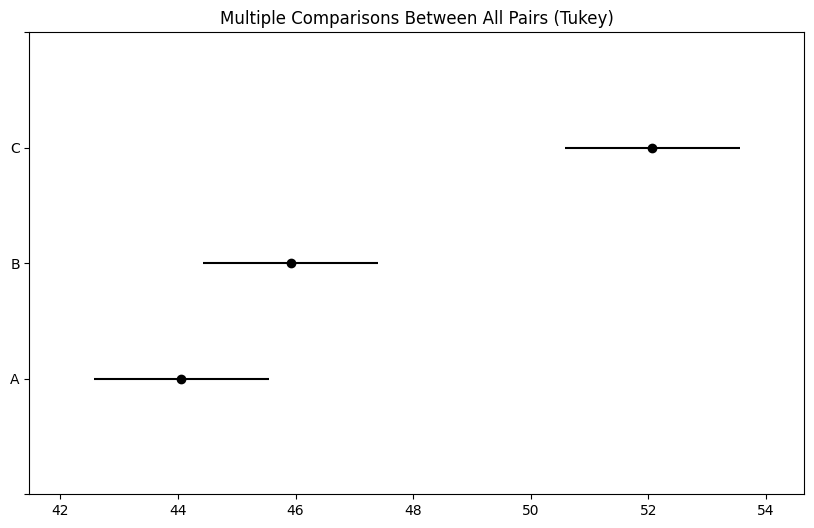

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Preparación de datos
datos_combinados = pd.DataFrame({'Valor': np.concatenate([grupo_A, grupo_B, grupo_C]),
                                 'Grupo': ['A']*30 + ['B']*30 + ['C']*30})

tukey = pairwise_tukeyhsd(endog=datos_combinados['Valor'],
                          groups=datos_combinados['Grupo'],
                          alpha=0.05)
print(tukey)
tukey.plot_simultaneous()
plt.show()

## Preguntas de Control:
### Respuestas a Preguntas de Control

#### 1. Verificación de Igualdad de Varianzas (Prueba de Levene)


In [26]:
import scipy.stats as stats

# Verificación de homocedasticidad para los 3 grupos
stat_levene, p_levene = stats.levene(grupo_A, grupo_B, grupo_C)

print(f"Estadístico de Levene: {stat_levene:.4f}")
print(f"p-valor: {p_levene:.4f}")

if p_levene >= 0.05:
    print("Resultado: Se cumple el supuesto de homocedasticidad (varianzas iguales).")
else:
    print("Resultado: Se viola el supuesto de homocedasticidad (varianzas diferentes).")


Estadístico de Levene: 0.4905
p-valor: 0.6140
Resultado: Se cumple el supuesto de homocedasticidad (varianzas iguales).


Discusión:

Alternativa no paramétrica: Kruskal-Wallis, ya que evalúa medianas/rangos sin asumir varianzas iguales ni normalidad. Se acompaña del post-hoc de Dunn.

Alternativa paramétrica: ANOVA de Welch con post-hoc Games-Howell (ideal si hay normalidad pero varianzas desiguales).

###Conclusiones:
Evaluación Algorítmica (Tarea 1): El ANOVA ($F = 22.61, p < 0.001$) y la prueba Tukey HSD confirmaron que el Algoritmo C es significativamente más rápido que A y B.

Análisis Regional (Tarea 2): La variable horas de estudio (s91p10) según el tipo de vivienda no mostró diferencias significativas ($p = 0.6675$). No se rechaza $H_0$ ni aplica Post-Hoc.

Validación de Supuestos: La prueba de Levene confirmó la homocedasticidad, garantizando la validez del modelo.

### Recomendaciones

1. **Modelos No Paramétricos:** Usar Kruskal-Wallis y prueba de Dunn si los datos reales violan la normalidad.
2. **Implementación:** Adoptar el Algoritmo C por su superioridad técnica en tiempos de ejecución.
3. **Análisis Avanzado:** Incluir más variables de control en la base regional mediante ANOVA de dos factores o ANCOVA.

###Bibliografía

* **Devore, J. L.** (2016). *Probabilidad y Estadística para Ingeniería y Ciencias* (9.ª ed.). Cengage Learning.
* **Montgomery, D. C.** (2020). *Design and Analysis of Experiments* (10th ed.). John Wiley & Sons.
* **Walpole, R. E., Myers, R. H., Myers, S. L., & Ye, K.** (2012). *Probabilidad y Estadística para Ingeniería y Ciencias* (9.ª ed.). Pearson Educación.

###Declaración de Uso de IA

* **Herramienta:** Gemini (IA Generativa).
* **Uso:** Asistencia en la redacción, formato y estructuración del informe.
* **Responsabilidad:** El código, los cálculos y la interpretación de resultados fueron ejecutados y validados por los autores.

https://gemini.google.com/app/0fe5d4710268e779?hl=es
